# Marketing Campaign Analytics - Data Profiling

- Dataset: Marketing Campaign Performance
- Rows: 2,020
- Columns: 12
- Purpose: Understand campaign-level marketing performance
Profiling objective: Assess completeness, consistency, validity and structure

| Column        | Expected Meaning           | Observed Type | Role                |
| ------------- | -------------------------- | ------------- | ------------------- |
| Campaign_ID   | Unique campaign identifier | object        | Identifier          |
| Campaign_Name | Campaign name              | object        | Descriptive         |
| Start_Date    | Campaign start             | object        | Date                |
| End_Date      | Campaign end               | object        | Date                |
| Channel       | Marketing channel          | object        | Categorical         |
| Impressions   | Ad impressions             | int64         | Numeric             |
| Clicks        | Ad clicks                  | int64         | Numeric             |
| Spend         | Campaign spend             | object        | Numeric             |
| Conversions   | Campaign conversions       | float64       | Numeric             |
| Active        | Campaign status            | object        | Boolean/categorical |
| Campaign_Tag  | Short channel/category tag | object        | Categorical         |


In [15]:
import pandas as pd
import matplotlib.pyplot as plt

In [16]:
df = pd.read_csv("marketing_campaign_data_messy.csv")

In [17]:
df.head()

,Campaign_ID,Campaign_Name,Start_Date,End_Date,Channel,Impressions,Clicks,Spend,Conversions,Active,Clicks,Campaign_Tag
0,CMP-00001,Q4_Summer_CMP-00001,2023-11-24 00:00:00,2023-12-13,TikTok,16795,197,$102.82,20.0,Y,NaN,TI
1,CMP-00002,Q1_Launch_CMP-00002,2023-05-06 00:00:00,2023-05-12,Facebook,1860,30,24.33,1.0,0,NaN,FA
2,CMP-00003,Q3_Winter_CMP-00003,2023-12-13 00:00:00,2023-12-20,Email,77820,843,1323.39,51.0,No,NaN,EM
3,CMP-00004,Q1_BlackFriday_CMP-00004,2023-10-30,2023-11-03,TikTok,55886,2019,2180.38,135.0,True,NaN,TI
4,CMP-00005,Q2_Winter_CMP-00005,2023-04-22 00:00:00,2023-04-23,Facebook,7265,169,252.44,30.0,Yes,NaN,FA


In [18]:
df.tail()

,Campaign_ID,Campaign_Name,Start_Date,End_Date,Channel,Impressions,Clicks,Spend,Conversions,Active,Clicks,Campaign_Tag
2015,CMP-00400,Q3_Summer_CMP-00400,2023-10-31 00:00:00,2023-11-13,TikTok,30592,586,$503.95,77.0,1,NaN,TI
2016,CMP-01255,Q4_Summer_CMP-01255,2023-09-01 00:00:00,2023-09-26,Google Ads,20097,897,1641.0,162.0,0,NaN,GO
2017,CMP-01050,Q2_Launch_CMP-01050,2023-02-09 00:00:00,2023-02-21,Instagram,33254,1117,883.82,214.0,0,NaN,IN
2018,CMP-01118,Q4_Winter_CMP-01118,2023-03-30 00:00:00,2023-04-27,Facebook,68728,2960,4198.5,591.0,Yes,NaN,FA
2019,CMP-01554,Q4_Launch_CMP-01554,2023-06-26 00:00:00,2023-07-09,Email,96402,1090,1315.59,66.0,Y,NaN,EM


In [19]:
df.shape

(2020, 12)

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2020 entries, 0 to 2019
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0    Campaign_ID   2020 non-null   object 
 1   Campaign_Name  2020 non-null   object 
 2   Start_Date     2020 non-null   object 
 3   End_Date       2020 non-null   object 
 4   Channel        1919 non-null   object 
 5   Impressions    2020 non-null   int64  
 6   Clicks         2020 non-null   int64  
 7   Spend          2020 non-null   object 
 8   Conversions    1820 non-null   float64
 9   Active         2020 non-null   object 
 10  Clicks         40 non-null     float64
 11  Campaign_Tag   2020 non-null   object 
dtypes: float64(2), int64(2), object(8)
memory usage: 189.5+ KB


# Findings from df.info()
#
# Dataset Overview:
- The dataset contains 2,020 entries and 12 columns.
- The dataset consists of 8 object, 2 int64, and 2 float64 columns.
#
# Missing Values:
- 'Channel' contains 101 missing values (1,919 non-null).
- 'Conversions' contains 200 missing values (1,820 non-null).
- The second 'Clicks' column contains 1,980 missing values, with only 40 non-null values. This column requires further investigation to determine its purpose and relationship with the primary 'Clicks' column.
#
# Column Naming Issues:
- 'Campaign_ID' contains leading/trailing whitespace.
- The second 'Clicks' column contains trailing whitespace in its column name.
#
# Data Type Observations:
- 'Start_Date' and 'End_Date' are currently stored as object types and should be investigated for conversion to datetime format.
- 'Spend' is stored as an object type and appears to contain mixed representations, requiring further investigation before converting it to a numeric format.
#
# Further Investigation:
- The duplicate 'Clicks' columns need to be investigated to determine whether the second column contains additional information, duplicate data, or data-quality issues.
- Missing values in 'Channel', 'Conversions', and the second 'Clicks' column should be investigated further before any cleaning or imputation decisions are made.

In [21]:
df.describe()

,Impressions,Clicks,Conversions,Clicks
count,2020.000000,2020.000000,1820.000000,40.000000
mean,49839.896040,1500.744059,186.085714,54856.200000
std,28579.637473,1084.765654,160.129172,30552.773369
min,1055.000000,11.000000,0.000000,2508.000000
25%,25033.500000,650.750000,68.000000,30164.750000
50%,50097.500000,1245.000000,142.000000,57707.500000
75%,74784.250000,2185.250000,257.000000,81497.500000
max,99875.000000,4812.000000,943.000000,99483.000000


# Findings from df.describe()

# Impressions:
 - Contains 2,020 observations with no missing values.
- Values range from 1,055 to 99,875.
- The mean is approximately 49,840, while the median is approximately 50,098, indicating a relatively balanced distribution around the center.
#
# Clicks:
- Contains 2,020 observations with no missing values.
- Values range from 11 to 4,812.
- The mean is approximately 1,501, while the median is 1,245.
- The difference between the mean and median suggests that the distribution may be influenced by higher click values and requires further investigation.

# Conversions:
- Contains 1,820 observations, indicating 200 missing values.
- Values range from 0 to 943.
- The mean is approximately 186, while the median is 142.
- The difference between the mean and median suggests the presence of higher conversion values that may require further investigation.

# Second 'Clicks' column:
- Contains only 40 non-null observations out of 2,020 records.
- Values range from 2,508 to 99,483.
- The mean is approximately 54,856, while the median is approximately 57,708.
- These values are substantially different from the primary 'Clicks' column, suggesting that this column requires further investigation before determining whether it represents duplicate, incorrectly mapped, or additional data.

# Overall Observations:
- The numeric columns show considerable variation between their minimum and maximum values.
- The mean and median differences in 'Clicks' and 'Conversions' indicate that their distributions should be examined further during EDA.
- The second 'Clicks' column has significantly fewer observations and a very different value range, making it unsuitable for direct comparison with the primary 'Clicks' column until its meaning is established.

# Column level profiling.

In [22]:
df.columns.tolist()

[' Campaign_ID ',
 'Campaign_Name',
 'Start_Date',
 'End_Date',
 'Channel',
 'Impressions',
 'Clicks ',
 'Spend',
 'Conversions',
 'Active',
 'Clicks',
 'Campaign_Tag']

In [23]:
#Checking for Campaign_ID column consistency

df[" Campaign_ID "].str.match(r"^CMP-\d{5}$").value_counts(dropna=False)

,count
Campaign_ID,
True,2020


In [24]:
df[" Campaign_ID "].map(type).value_counts()

,count
Campaign_ID,
<class 'str'>,2020


In [25]:
#Renaming the duplicate clicks columns to clicks_1 and click_2 for further investigation.

df = df.rename(
    columns = {
            "Clicks ": "clicks_1",
            "Clicks": "clicks_2"
      }
)

In [26]:
#Checking for trailing spaces
whitespace_columns = [
    col for col in df.columns
    if col != col.strip()
]

whitespace_columns

[' Campaign_ID ']

#Column level profiling

In [27]:
print("Dtype of Campaign_Name:", df["Campaign_Name"].dtype)
print("Number of Unique values:", df["Campaign_Name"].nunique())

Dtype of Campaign_Name: object
Number of Unique values: 2000


In [28]:
print("Total value counts:", df["Campaign_Name"].value_counts())

Total value counts: Campaign_Name
Q1_Winter_CMP-01321         2
Q1_Launch_CMP-00439         2
Q3_Launch_CMP-01426         2
Q3_Launch_CMP-00185         2
Q3_Winter_CMP-01559         2
                           ..
Q3_Winter_CMP-00663         1
Q1_BlackFriday_CMP-00662    1
Q1_BlackFriday_CMP-00661    1
Q1_BlackFriday_CMP-00660    1
Q3_Launch_CMP-00675         1
Name: count, Length: 2000, dtype: int64


In [29]:
print("Null values in Campaign_Name column:", df["Campaign_Name"].isna().sum())

Null values in Campaign_Name column: 0


In [30]:
print("Unique values in Campaign_Name column:", df["Campaign_Name"].unique())

Unique values in Campaign_Name column: ['Q4_Summer_CMP-00001' 'Q1_Launch_CMP-00002' 'Q3_Winter_CMP-00003' ...
 'Q4_BlackFriday_CMP-01998' 'Q1_Launch_CMP-01999' 'Q2_Winter_CMP-02000']


In [31]:
df["Campaign_Name"].map(type).value_counts()

,count
Campaign_Name,
<class 'str'>,2020


In [32]:
print("Dtype of Channel:", df["Channel"].dtype)
print("Null values in Channel column:", df["Channel"].isna().sum())
print("Number of Unique values:", df["Channel"].nunique())
print("Unique values in Channel column:", df["Channel"].unique())
print("Total value counts:", df["Channel"].value_counts())

Dtype of Channel: object
Null values in Channel column: 101
Number of Unique values: 10
Unique values in Channel column: ['TikTok' 'Facebook' 'Email' 'Instagram' 'Google Ads' 'E-mail' nan 'Gogle'
 'Tik_Tok' 'Facebok' 'Insta_gram']
Total value counts: Channel
TikTok        399
Facebook      391
Email         359
Google Ads    346
Instagram     340
E-mail         21
Insta_gram     19
Tik_Tok        16
Gogle          14
Facebok        14
Name: count, dtype: int64


In [33]:
df["Channel"].map(type).value_counts()

,count
Channel,
<class 'str'>,1919
<class 'float'>,101


In [34]:
# Viewing non-missing unique values in alphabetical order
channel_values = df["Channel"].dropna().unique()

for value in sorted(channel_values):
    print(value)

E-mail
Email
Facebok
Facebook
Gogle
Google Ads
Insta_gram
Instagram
TikTok
Tik_Tok


In [35]:
campaign_name_check = (
    df.groupby(" Campaign_ID ")["Campaign_Name"]
      .nunique()
      .sort_values(ascending=False)
)

display(campaign_name_check.head(20))

,Campaign_Name
Campaign_ID,
CMP-01984,1
CMP-01983,1
CMP-01982,1
CMP-01981,1
CMP-01980,1
CMP-01979,1
CMP-01978,1
CMP-01977,1
CMP-01976,1


In [36]:
campaign_name_check[campaign_name_check > 1]

,Campaign_Name
Campaign_ID,


In [37]:
print("Dtype of Campaign_Tag:", df["Campaign_Tag"].dtype)
print("Null values in Campaign_Tag column:", df["Campaign_Tag"].isna().sum())
print("Number of Unique values:", df["Campaign_Tag"].nunique())
print("Unique values in Campaign_Tag column:", df["Campaign_Tag"].unique())
print("Total value counts:", df["Campaign_Tag"].value_counts())

Dtype of Campaign_Tag: object
Null values in Campaign_Tag column: 0
Number of Unique values: 8
Unique values in Campaign_Tag column: ['TI' 'FA' 'EM' 'IN' 'GO' 'E-' 'INVALID' 'XX']
Total value counts: Campaign_Tag
TI         400
FA         391
IN         343
GO         337
EM         335
INVALID    101
XX          93
E-          20
Name: count, dtype: int64


In [38]:
print("Dtype of Active:", df["Active"].dtype)
print("Null values in Active column:", df["Active"].isna().sum())
print("Number of Unique values:", df["Active"].nunique())
print("Unique values in Active column:", df["Active"].unique())
print("Total value counts:", df["Active"].value_counts())

Dtype of Active: object
Null values in Active column: 0
Number of Unique values: 7
Unique values in Active column: ['Y' '0' 'No' 'True' 'Yes' '1' 'False']
Total value counts: Active
1        319
Yes      306
True     297
No       291
False    281
Y        273
0        253
Name: count, dtype: int64


# Numeric column profiling

In [39]:
df["Spend"].info()

<class 'pandas.core.series.Series'>
RangeIndex: 2020 entries, 0 to 2019
Series name: Spend
Non-Null Count  Dtype 
--------------  ----- 
2020 non-null   object
dtypes: object(1)
memory usage: 15.9+ KB


In [40]:
df["Spend"].head(20)

,Spend
0,$102.82
1,24.33
2,1323.39
3,2180.38
4,252.44
5,2697.03
6,1232.76
7,865.7
8,1046.18
9,1623.56


In [41]:
df["Spend"].astype(str).str.contains(r"[$,]").sum()

np.int64(298)

In [42]:
df["Spend"].astype(str).str.strip().value_counts().head(20)

,count
Spend,
500000.0,5
883.82,2
1315.59,2
1371.03,2
1796.19,2
5093.82,2
$2640.72,2
$503.95,2
460.42,2


In [47]:
spend_numeric = (
    df["Spend"].str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(float)
)

In [48]:
spend_numeric.describe()

,Spend
count,2020.000000
mean,3094.844970
std,24811.020701
min,-2503.310000
25%,649.997500
50%,1427.105000
75%,2638.382500
max,500000.000000


In [58]:
spend_numeric.isna().sum()

np.int64(0)

In [108]:
pd.DataFrame({
    "spend": df["Spend"],
    "spend_numeric": spend_numeric
}).head(20)

,spend,spend_numeric
0,$102.82,102.82
1,24.33,24.33
2,1323.39,1323.39
3,2180.38,2180.38
4,252.44,252.44
5,2697.03,2697.03
6,1232.76,1232.76
7,865.7,865.70
8,1046.18,1046.18
9,1623.56,1623.56


In [110]:
df["spend_numeric"] = spend_numeric

In [111]:
  negative_spend = df[df['spend_numeric'] < 0]

  negative_spend

,Campaign_ID,Campaign_Name,Start_Date,End_Date,Channel,Impressions,clicks_1,Spend,Conversions,Active,clicks_2,Campaign_Tag,clicks_2_difference,spend_numeric
144,CMP-00145,Q2_Summer_CMP-00145,2023-12-07 00:00:00,2023-12-14,Facebook,51636,1859,-1407.54,270.0,Y,NaN,FA,NaN,-1407.54
407,CMP-00408,Q1_BlackFriday_CMP-00408,2023-05-21 00:00:00,2023-05-28,Facebok,78575,2058,-1214.52,119.0,0,NaN,FA,NaN,-1214.52
576,CMP-00577,Q4_Launch_CMP-00577,2023-06-30 00:00:00,2023-07-13,Facebook,90084,940,-821.8,178.0,No,NaN,FA,NaN,-821.80
604,CMP-00605,Q2_BlackFriday_CMP-00605,2023-02-03 00:00:00,2023-02-25,Email,42555,515,-942.8,57.0,1,NaN,EM,NaN,-942.80
676,CMP-00677,Q3_BlackFriday_CMP-00677,2023-10-15 00:00:00,2023-10-26,TikTok,41262,1025,-1640.88,64.0,False,NaN,TI,NaN,-1640.88
817,CMP-00818,Q1_Launch_CMP-00818,2023-09-05,2023-05-16,Email,35816,1291,-1261.81,82.0,Y,35860.0,EM,44.0,-1261.81
886,CMP-00887,Q4_Summer_CMP-00887,2023-07-29 00:00:00,2023-08-13,Google Ads,70836,2292,-2162.5,150.0,Yes,NaN,GO,NaN,-2162.50
924,CMP-00925,Q4_Launch_CMP-00925,2023-02-28 00:00:00,2023-03-15,Facebook,23574,1054,-648.3,104.0,Yes,NaN,FA,NaN,-648.30
1125,CMP-01126,Q1_Launch_CMP-01126,2023-11-11 00:00:00,2023-12-11,TikTok,12302,204,-122.8,25.0,Yes,NaN,TI,NaN,-122.80
1142,CMP-01143,Q1_BlackFriday_CMP-01143,2023-11-10 00:00:00,2023-12-01,NaN,1922,29,-20.05,2.0,1,NaN,XX,NaN,-20.05


In [112]:
negative_spend[
    [' Campaign_ID ',
     'Campaign_Name',
     'Start_Date',
     'End_Date',
     'Channel',
     'Impressions',
     'clicks_1',
     'Spend',
     'Conversions',
     'Active',
     'clicks_2',
     'Campaign_Tag'
    ]
]

,Campaign_ID,Campaign_Name,Start_Date,End_Date,Channel,Impressions,clicks_1,Spend,Conversions,Active,clicks_2,Campaign_Tag
144,CMP-00145,Q2_Summer_CMP-00145,2023-12-07 00:00:00,2023-12-14,Facebook,51636,1859,-1407.54,270.0,Y,NaN,FA
407,CMP-00408,Q1_BlackFriday_CMP-00408,2023-05-21 00:00:00,2023-05-28,Facebok,78575,2058,-1214.52,119.0,0,NaN,FA
576,CMP-00577,Q4_Launch_CMP-00577,2023-06-30 00:00:00,2023-07-13,Facebook,90084,940,-821.8,178.0,No,NaN,FA
604,CMP-00605,Q2_BlackFriday_CMP-00605,2023-02-03 00:00:00,2023-02-25,Email,42555,515,-942.8,57.0,1,NaN,EM
676,CMP-00677,Q3_BlackFriday_CMP-00677,2023-10-15 00:00:00,2023-10-26,TikTok,41262,1025,-1640.88,64.0,False,NaN,TI
817,CMP-00818,Q1_Launch_CMP-00818,2023-09-05,2023-05-16,Email,35816,1291,-1261.81,82.0,Y,35860.0,EM
886,CMP-00887,Q4_Summer_CMP-00887,2023-07-29 00:00:00,2023-08-13,Google Ads,70836,2292,-2162.5,150.0,Yes,NaN,GO
924,CMP-00925,Q4_Launch_CMP-00925,2023-02-28 00:00:00,2023-03-15,Facebook,23574,1054,-648.3,104.0,Yes,NaN,FA
1125,CMP-01126,Q1_Launch_CMP-01126,2023-11-11 00:00:00,2023-12-11,TikTok,12302,204,-122.8,25.0,Yes,NaN,TI
1142,CMP-01143,Q1_BlackFriday_CMP-01143,2023-11-10 00:00:00,2023-12-01,NaN,1922,29,-20.05,2.0,1,NaN,XX


In [60]:
#Checking for missing values in other numeric columns

print("Missing values in clicks_1:", df["clicks_1"].isna().sum())
print("Missing values in clicks_2:", df["clicks_2"].isna().sum())
print("Missing values in Impressions:", df["Impressions"].isna().sum())
print("Missing values in Conversions:", df["Conversions"].isna().sum())

Missing values in clicks_1: 0
Missing values in clicks_2: 1980
Missing values in Impressions: 0
Missing values in Conversions: 200


In [61]:
# Checking for negative values in other numeric columns - Clicks, Impressions, Conversions

numeric_cols = ["Impressions", "clicks_1", "clicks_2", "Conversions"]

for col in numeric_cols:
    print(f"{col}: {(df[col] < 0).sum()} negative values")

Impressions: 0 negative values
clicks_1: 0 negative values
clicks_2: 0 negative values
Conversions: 0 negative values


In [62]:
for col in numeric_cols:
    negative_rows = df.loc[df[col] < 0, [" Campaign_ID ", col]]

    if not negative_rows.empty:
        print(f"\n{col}")
        print(negative_rows)

There are no negative records in other numeric columns. `Clicks`, `Impressions` & `Conversions`.

#Duplicate record check - checking for campaigns duplicate records.

In [63]:
# The two Clicks-related columns have different names because one contains trailing whitespace.
df.columns.duplicated()

array([False, False, False, False, False, False, False, False, False,
       False, False, False])

In [64]:
# Checking for duplicate records
df.duplicated().sum()

np.int64(19)

In [65]:
df[" Campaign_ID "].nunique()

2000

In [66]:
duplicated_campaigns = df[
    df[" Campaign_ID "].duplicated(keep=False)
].sort_values(" Campaign_ID ")

display(duplicated_campaigns)

,Campaign_ID,Campaign_Name,Start_Date,End_Date,Channel,Impressions,clicks_1,Spend,Conversions,Active,clicks_2,Campaign_Tag
184,CMP-00185,Q3_Launch_CMP-00185,2023-08-03 00:00:00,2023-08-27,Facebok,56016,1728,1890.33,128.0,No,NaN,FA
2014,CMP-00185,Q3_Launch_CMP-00185,2023-08-03 00:00:00,2023-08-27,Facebok,56016,1728,1890.33,128.0,No,NaN,FA
387,CMP-00388,Q1_Summer_CMP-00388,2023-06-20 00:00:00,2023-06-25,TikTok,57958,2328,$2135.23,280.0,Y,NaN,TI
2013,CMP-00388,Q1_Summer_CMP-00388,2023-06-20 00:00:00,2023-06-25,TikTok,57958,2328,$2135.23,280.0,Y,NaN,TI
399,CMP-00400,Q3_Summer_CMP-00400,2023-10-31 00:00:00,2023-11-13,TikTok,30592,586,$503.95,77.0,1,NaN,TI
2015,CMP-00400,Q3_Summer_CMP-00400,2023-10-31 00:00:00,2023-11-13,TikTok,30592,586,$503.95,77.0,1,NaN,TI
438,CMP-00439,Q1_Launch_CMP-00439,2023-08-03 00:00:00,2023-08-27,Google Ads,88235,3182,5093.82,385.0,1,NaN,GO
2010,CMP-00439,Q1_Launch_CMP-00439,2023-08-03 00:00:00,2023-08-27,Google Ads,88235,3182,5093.82,385.0,1,NaN,GO
2011,CMP-01028,Q4_Summer_CMP-01028,2023-12-24 00:00:00,2024-01-05,TikTok,54441,2158,$2422.76,252.0,Yes,NaN,TI
1027,CMP-01028,Q4_Summer_CMP-01028,2023-12-24 00:00:00,2024-01-05,TikTok,54441,2158,$2422.76,252.0,Yes,NaN,TI


# Missing Values

In [67]:
df.isna().sum().sort_values(ascending=False)

,0
clicks_2,1980
Conversions,200
Channel,101
Campaign_ID,0
End_Date,0
Start_Date,0
Campaign_Name,0
Impressions,0
Spend,0
clicks_1,0


In [68]:
missing_profiles = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_pct": df.isna().mean()*100,
    "non_missing_count": df.notna().sum()
})

missing_profiles = missing_profiles.sort_values(
    "missing_pct",
    ascending=False
)
missing_profiles["missing_pct"] = missing_profiles["missing_pct"].round(2)

display(missing_profiles)

,missing_count,missing_pct,non_missing_count
clicks_2,1980,98.02,40
Conversions,200,9.90,1820
Channel,101,5.00,1919
Campaign_ID,0,0.00,2020
End_Date,0,0.00,2020
Start_Date,0,0.00,2020
Campaign_Name,0,0.00,2020
Impressions,0,0.00,2020
Spend,0,0.00,2020
clicks_1,0,0.00,2020


In [69]:
rows_with_missing = df.isna().any(axis=1).sum()
rows_with_2plus_missing = (df.isna().sum(axis=1) >= 2).sum()
complete_rows = df.notna().all(axis=1).sum()

print("Rows with at least one missing value:", rows_with_missing)
print("Rows with 2+ missing values:", rows_with_2plus_missing)
print("Complete rows:", complete_rows)

Rows with at least one missing value: 1985
Rows with 2+ missing values: 288
Complete rows: 35


## Cardinality profiling

In [70]:
df.nunique()

,0
Campaign_ID,2000
Campaign_Name,2000
Start_Date,624
End_Date,387
Channel,10
Impressions,1983
clicks_1,1503
Spend,1993
Conversions,528
Active,7


## Categorical value profiling

In [71]:
df["Channel"].value_counts(dropna=False)

,count
Channel,
TikTok,399
Facebook,391
Email,359
Google Ads,346
Instagram,340
NaN,101
E-mail,21
Insta_gram,19
Tik_Tok,16


Channel column has 101 NaN values that needs to be further needs to checked.

In [72]:
df["Active"].value_counts(normalize=True) * 100

,proportion
Active,
1,15.792079
Yes,15.148515
True,14.702970
No,14.405941
False,13.910891
Y,13.514851
0,12.524752


In [73]:
df["Campaign_Tag"].value_counts(dropna=False)

,count
Campaign_Tag,
TI,400
FA,391
IN,343
GO,337
EM,335
INVALID,101
XX,93
E-,20


Campaign Tag has `Invalid` 101, `E-` 20 and `XX` 93 values that needs to be checked.

## Date Profiling

In [74]:
df["Start_Date"].head(20)

,Start_Date
0,2023-11-24 00:00:00
1,2023-05-06 00:00:00
2,2023-12-13 00:00:00
3,2023-10-30
4,2023-04-22 00:00:00
5,2023-10-15 00:00:00
6,2023-10-07 00:00:00
7,2023-05-23
8,2023-03-23 00:00:00
9,2023-03-21 00:00:00


In [75]:
df["End_Date"].head(20)

,End_Date
0,2023-12-13
1,2023-05-12
2,2023-12-20
3,2023-11-03
4,2023-04-23
5,2023-10-28
6,2023-10-23
7,2023-05-28
8,2023-04-01
9,2023-04-01


In [76]:
df["Start_Date"].astype(str).str.contains("/").sum()

np.int64(185)

In [77]:
start_date = pd.to_datetime(
    df["Start_Date"],
    format = "mixed",
    dayfirst=True
)

In [78]:
print("Invalide Start Date:", start_date.isna().sum())

Invalide Start Date: 0


In [79]:
end_date = pd.to_datetime(
    df["End_Date"],
    format = "mixed",
    dayfirst=True
)

In [80]:
print("Invalid end date:", end_date.isna().sum())

Invalid end date: 0


In [81]:
invalid_dates = end_date < start_date
print("Invalid date relationship:", invalid_dates.sum())

Invalid date relationship: 78


In [82]:
campaign_duration = end_date - start_date

campaign_duration.describe()

,0
count,2020
mean,13 days 15:26:43.960396039
std,30 days 22:54:52.153507283
min,-294 days +00:00:00
25%,7 days 00:00:00
50%,15 days 00:00:00
75%,23 days 00:00:00
max,285 days 00:00:00


In [83]:
(end_date == start_date).sum()

np.int64(0)

## Checking both clicks columns against impressions and conversions columns



In [84]:
# checking for column indexs.

for i, col in enumerate(df.columns):
  print(i, repr(col))

0 ' Campaign_ID '
1 'Campaign_Name'
2 'Start_Date'
3 'End_Date'
4 'Channel'
5 'Impressions'
6 'clicks_1'
7 'Spend'
8 'Conversions'
9 'Active'
10 'clicks_2'
11 'Campaign_Tag'


In [85]:
for i, col in enumerate(df.columns):
  if "clicks" in col.lower():
    print(i, repr(col))

6 'clicks_1'
10 'clicks_2'


In [86]:
clicks_columns = [
    col for col in df.columns
    if "clicks" in col.lower()
]
print(clicks_columns)

['clicks_1', 'clicks_2']


In [87]:
df[clicks_columns].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2020 entries, 0 to 2019
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   clicks_1  2020 non-null   int64  
 1   clicks_2  40 non-null     float64
dtypes: float64(1), int64(1)
memory usage: 31.7 KB


In [88]:
df[clicks_columns].isna().sum()

,0
clicks_1,0
clicks_2,1980


In [89]:
df[clicks_columns].notna().sum(axis=1).value_counts()

,count
1,1980
2,40


In [91]:
df.columns

Index([' Campaign_ID ', 'Campaign_Name', 'Start_Date', 'End_Date', 'Channel',
       'Impressions', 'clicks_1', 'Spend', 'Conversions', 'Active', 'clicks_2',
       'Campaign_Tag'],
      dtype='object')

In [92]:
df.loc[
    df["clicks_1"].isna() | df["clicks_2"].isna(),
    ["clicks_1", "clicks_2"]
]

,clicks_1,clicks_2
0,197,NaN
1,30,NaN
2,843,NaN
3,2019,NaN
4,169,NaN
...,...,...
2015,586,NaN
2016,897,NaN
2017,1117,NaN
2018,2960,NaN


In [93]:
df.loc[
    df["clicks_2"].notna(),
    ["Impressions", "clicks_1", "clicks_2"]
]

,Impressions,clicks_1,clicks_2
22,86305,2637,86385.0
43,81038,2149,81075.0
63,78189,2164,78213.0
88,87807,3125,87884.0
139,91982,4574,92026.0
143,24419,350,24436.0
156,82734,2912,82765.0
200,69840,2185,69935.0
288,16151,406,16169.0
305,3200,92,3228.0


In [94]:
df.loc[
    df["clicks_2"] > df["Impressions"],
    [" Campaign_ID ", "Impressions", "clicks_1", "clicks_2"]
]

,Campaign_ID,Impressions,clicks_1,clicks_2
22,CMP-00023,86305,2637,86385.0
43,CMP-00044,81038,2149,81075.0
63,CMP-00064,78189,2164,78213.0
88,CMP-00089,87807,3125,87884.0
139,CMP-00140,91982,4574,92026.0
143,CMP-00144,24419,350,24436.0
156,CMP-00157,82734,2912,82765.0
200,CMP-00201,69840,2185,69935.0
288,CMP-00289,16151,406,16169.0
305,CMP-00306,3200,92,3228.0


In [95]:
(df["clicks_2"] > df["Impressions"]).sum()

np.int64(40)

# `clicks_2` is greater than impressions violating the business rule.

In [ ]:
# Checking Impressions <= sparse Clicks field
df[df["clicks_1"] > df["Impressions"]]

,Campaign_ID,Campaign_Name,Start_Date,End_Date,Channel,Impressions,clicks_1,Spend,Conversions,Active,clicks_2,Campaign_Tag,Spend_numeric


In [96]:
df["clicks_2_difference"] = (
    df["clicks_2"] - df["Impressions"]
)

In [97]:
df.loc[
    df["clicks_2"].notna(),
    [" Campaign_ID ", "Impressions", "clicks_1", "clicks_2", "clicks_2_difference"]
]

,Campaign_ID,Impressions,clicks_1,clicks_2,clicks_2_difference
22,CMP-00023,86305,2637,86385.0,80.0
43,CMP-00044,81038,2149,81075.0,37.0
63,CMP-00064,78189,2164,78213.0,24.0
88,CMP-00089,87807,3125,87884.0,77.0
139,CMP-00140,91982,4574,92026.0,44.0
143,CMP-00144,24419,350,24436.0,17.0
156,CMP-00157,82734,2912,82765.0,31.0
200,CMP-00201,69840,2185,69935.0,95.0
288,CMP-00289,16151,406,16169.0,18.0
305,CMP-00306,3200,92,3228.0,28.0


In [99]:
# Checking Impressions <= primary Clicks field
df[df["clicks_1"] > df["Impressions"]]

,Campaign_ID,Campaign_Name,Start_Date,End_Date,Channel,Impressions,clicks_1,Spend,Conversions,Active,clicks_2,Campaign_Tag,clicks_2_difference


In [100]:
# Checking Impressions <= sparse Clicks field
df[df["Conversions"] > df["clicks_1"]]

,Campaign_ID,Campaign_Name,Start_Date,End_Date,Channel,Impressions,clicks_1,Spend,Conversions,Active,clicks_2,Campaign_Tag,clicks_2_difference


In [101]:
# Checking Conversions <= primary Clicks field
df[df["Conversions"] > df["clicks_1"]]

,Campaign_ID,Campaign_Name,Start_Date,End_Date,Channel,Impressions,clicks_1,Spend,Conversions,Active,clicks_2,Campaign_Tag,clicks_2_difference


In [103]:
valid_rows = df[
    df["Conversions"].notna() &
    df["clicks_1"].notna()
]

(valid_rows["Conversions"] > valid_rows["clicks_1"]).sum()

np.int64(0)

In [105]:
valid_rows = df[
    df["clicks_2"].notna() &
    df["Impressions"].notna()
]

(valid_rows["clicks_2"] > valid_rows["Impressions"]).sum()

np.int64(40)

## Outlier Detection

In [ ]:
df.describe()

,Impressions,clicks_1,Conversions,clicks_2,Spend_numeric
count,2020.000000,2020.000000,1820.000000,40.000000,1722.000000
mean,49839.896040,1500.744059,186.085714,54856.200000,3307.144913
std,28579.637473,1084.765654,160.129172,30552.773369,26860.112660
min,1055.000000,11.000000,0.000000,2508.000000,-2503.310000
25%,25033.500000,650.750000,68.000000,30164.750000,652.950000
50%,50097.500000,1245.000000,142.000000,57707.500000,1429.380000
75%,74784.250000,2185.250000,257.000000,81497.500000,2624.892500
max,99875.000000,4812.000000,943.000000,99483.000000,500000.000000


## Distribution and Outlier Profiling

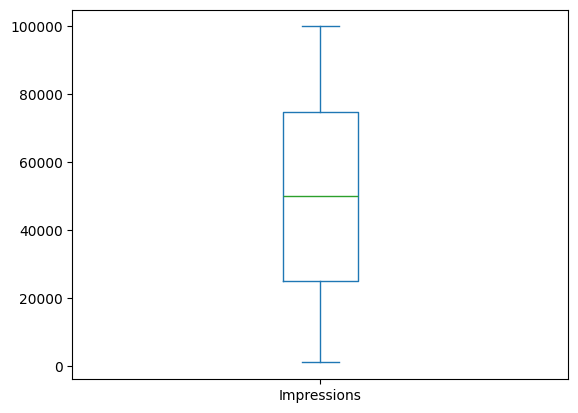

In [ ]:
df["Impressions"].plot(kind="box")
plt.show()

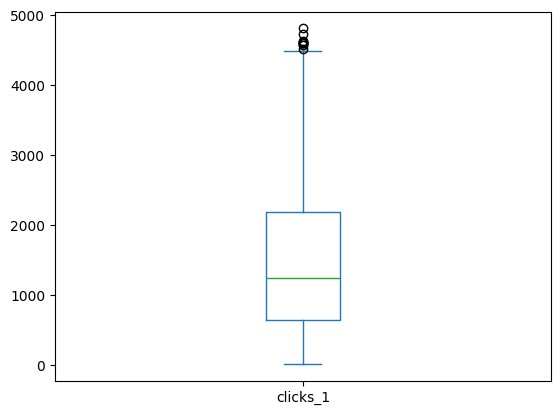

In [ ]:
df["clicks_1"].plot(kind="box")
plt.show()

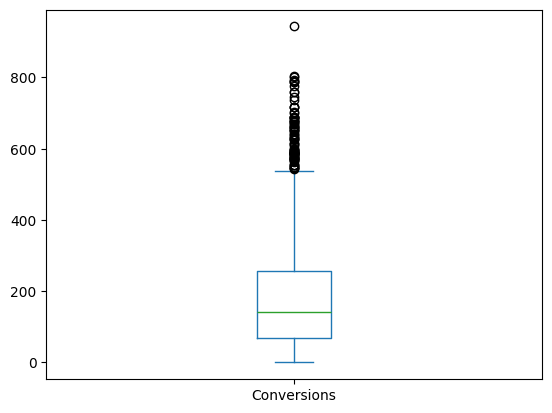

In [ ]:
df["Conversions"].plot(kind="box")
plt.show()

In [ ]:
df["Impressions"].skew()

np.float64(0.009348447530933151)

In [ ]:
df["clicks_1"].skew()

np.float64(0.780937461256074)

In [ ]:
df["clicks_2"].skew()

np.float64(-0.1963156205749838)

In [ ]:
df["Conversions"].skew()

np.float64(1.3684537518853066)

In [ ]:
numeric_columns = ["Impressions", "clicks_1", "clicks_2", "Conversions"]

for col in numeric_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ]

    print(f"{col}")
    print(f"Lower bound: {lower_bound:.2f}")
    print(f"Upper bound: {upper_bound:.2f}")
    print(f"Outliers: {len(outliers)}")
    print()



Impressions
Lower bound: -49592.62
Upper bound: 149410.38
Outliers: 0

clicks_1
Lower bound: -1651.00
Upper bound: 4487.00
Outliers: 11

clicks_2
Lower bound: -46834.38
Upper bound: 158496.62
Outliers: 0

Conversions
Lower bound: -215.50
Upper bound: 540.50
Outliers: 88



In [ ]:
#Outlier %

outlier_pct = len(outliers) / len(df) * 100
print(outlier_pct)

4.356435643564356


## Cross column consistency

In [ ]:
pd.crosstab(
    df["Channel"],
    df["Campaign_Tag"]
)

Campaign_Tag,E-,EM,FA,GO,IN,INVALID,TI
Channel,,,,,,,
E-mail,20,0,0,0,0,1,0
Email,0,335,0,0,0,24,0
Facebok,0,0,13,0,0,1,0
Facebook,0,0,378,0,0,13,0
Gogle,0,0,0,13,0,1,0
Google Ads,0,0,0,324,0,22,0
Insta_gram,0,0,0,0,19,0,0
Instagram,0,0,0,0,324,16,0
TikTok,0,0,0,0,0,15,384


The cross-tabulation reveals recurring relationships between Channel labels and Campaign Tags, including TikTok/Tik_Tok → TI and Facebook/Facebok → FA. These relationships may help validate and standardize categorical values during cleaning.

## Missingness pattern

In [107]:
missing_rows = df[df.isna().any(axis=1)]
display(missing_rows.head(20))

,Campaign_ID,Campaign_Name,Start_Date,End_Date,Channel,Impressions,clicks_1,Spend,Conversions,Active,clicks_2,Campaign_Tag,clicks_2_difference
0,CMP-00001,Q4_Summer_CMP-00001,2023-11-24 00:00:00,2023-12-13,TikTok,16795,197,$102.82,20.0,Y,NaN,TI,NaN
1,CMP-00002,Q1_Launch_CMP-00002,2023-05-06 00:00:00,2023-05-12,Facebook,1860,30,24.33,1.0,0,NaN,FA,NaN
2,CMP-00003,Q3_Winter_CMP-00003,2023-12-13 00:00:00,2023-12-20,Email,77820,843,1323.39,51.0,No,NaN,EM,NaN
3,CMP-00004,Q1_BlackFriday_CMP-00004,2023-10-30,2023-11-03,TikTok,55886,2019,2180.38,135.0,True,NaN,TI,NaN
4,CMP-00005,Q2_Winter_CMP-00005,2023-04-22 00:00:00,2023-04-23,Facebook,7265,169,252.44,30.0,Yes,NaN,FA,NaN
5,CMP-00006,Q4_BlackFriday_CMP-00006,2023-10-15 00:00:00,2023-10-28,Instagram,83386,2643,2697.03,NaN,1,NaN,IN,NaN
6,CMP-00007,Q3_Launch_CMP-00007,2023-10-07 00:00:00,2023-10-23,Facebook,38194,1135,1232.76,178.0,Yes,NaN,FA,NaN
7,CMP-00008,Q4_Launch_CMP-00008,2023-05-23,2023-05-28,Instagram,88498,1173,865.7,127.0,1,NaN,IN,NaN
8,CMP-00009,Q4_BlackFriday_CMP-00009,2023-03-23 00:00:00,2023-04-01,Google Ads,45131,1179,1046.18,104.0,1,NaN,GO,NaN
9,CMP-00010,Q2_Winter_CMP-00010,2023-03-21 00:00:00,2023-04-01,Email,61263,1153,1623.56,NaN,0,NaN,EM,NaN


In [ ]:
missing_pattern = df.isna().sum(axis=1).value_counts().sort_index()
display(missing_pattern)

,count
0,32
1,1449
2,489
3,48
4,2


Missingness is widespread across the dataset, with only 35 of 2,020 rows being completely populated.

In [ ]:
missing_by_column = df.isna()

display(missing_by_column.head(20))

,Campaign_ID,Campaign_Name,Start_Date,End_Date,Channel,Impressions,clicks_1,Spend,Conversions,Active,clicks_2,Campaign_Tag,Spend_numeric
0,False,False,False,False,False,False,False,False,False,False,True,False,True
1,False,False,False,False,False,False,False,False,False,False,True,False,False
2,False,False,False,False,False,False,False,False,False,False,True,False,False
3,False,False,False,False,False,False,False,False,False,False,True,False,False
4,False,False,False,False,False,False,False,False,False,False,True,False,False
5,False,False,False,False,False,False,False,False,True,False,True,False,False
6,False,False,False,False,False,False,False,False,False,False,True,False,False
7,False,False,False,False,False,False,False,False,False,False,True,False,False
8,False,False,False,False,False,False,False,False,False,False,True,False,False
9,False,False,False,False,False,False,False,False,True,False,True,False,False


In [ ]:
missing_patterns = (
    df.isna()
      .value_counts()
      .reset_index(name="row_count")
)

display(missing_patterns)

,Campaign_ID,Campaign_Name,Start_Date,End_Date,Channel,Impressions,clicks_1,Spend,Conversions,Active,clicks_2,Campaign_Tag,Spend_numeric,row_count
0,False,False,False,False,False,False,False,False,False,False,True,False,False,1441
1,False,False,False,False,False,False,False,False,False,False,True,False,True,251
2,False,False,False,False,False,False,False,False,True,False,True,False,False,160
3,False,False,False,False,True,False,False,False,False,False,True,False,False,78
4,False,False,False,False,False,False,False,False,False,False,False,False,False,32
5,False,False,False,False,False,False,False,False,True,False,True,False,True,29
6,False,False,False,False,True,False,False,False,False,False,True,False,True,13
7,False,False,False,False,True,False,False,False,True,False,True,False,False,6
8,False,False,False,False,False,False,False,False,False,False,False,False,True,3
9,False,False,False,False,False,False,False,False,True,False,False,False,False,3


In [ ]:
df[
    df["Channel"].isna() &
    df["Conversions"].isna()
].shape[0]

8

In [ ]:
df[
    df["Channel"].isna() &
    df["clicks_1"].isna()
].shape[0]

0

In [ ]:
df[
    df["Channel"].isna() &
    df["clicks_2"].isna()
].shape[0]

99

In [ ]:
df[
    df["Conversions"].isna() &
    df["clicks_1"].isna()
].shape[0]

0

In [ ]:
df[
    df["Conversions"].isna() &
    df["clicks_2"].isna()
].shape[0]

197

In [ ]:
df[
    df["Channel"].isna() &
    df["Conversions"].isna() &
    df["clicks_1"].isna()
].shape[0]

0

In [ ]:
df[
    df["Channel"].isna() &
    df["Conversions"].isna() &
    df["clicks_2"].isna()
].shape[0]

8

# Checking if missingness is concentrated by segment.

In [ ]:
channel_missing_by_tag = (
    df.groupby("Campaign_Tag")["Channel"]
      .apply(lambda x: x.isna().sum())
)

display(channel_missing_by_tag)

,Channel
Campaign_Tag,
E-,0
EM,0
FA,0
GO,0
IN,0
INVALID,8
TI,0
XX,93


In [ ]:
channel_missing_by_tag = (
    df.groupby("Campaign_Tag")["Channel"]
      .agg(
          total_rows="size",
          missing_channel=lambda x: x.isna().sum()
      )
)

channel_missing_by_tag["missing_pct"] = (
    channel_missing_by_tag["missing_channel"]
    / channel_missing_by_tag["total_rows"]
    * 100
).round(2)

display(channel_missing_by_tag)

,total_rows,missing_channel,missing_pct
Campaign_Tag,,,
E-,20,0,0.00
EM,335,0,0.00
FA,391,0,0.00
GO,337,0,0.00
IN,343,0,0.00
INVALID,101,8,7.92
TI,400,0,0.00
XX,93,93,100.00


In [ ]:
conversion_missing_by_channel = (
    df.groupby("Channel")["Conversions"]
      .agg(
          total_rows="size",
          missing_conversions=lambda x: x.isna().sum()
      )
)

conversion_missing_by_channel["missing_pct"] = (
    conversion_missing_by_channel["missing_conversions"]
    / conversion_missing_by_channel["total_rows"] * 100
).round(2)

display(conversion_missing_by_channel)

,total_rows,missing_conversions,missing_pct
Channel,,,
E-mail,21,2,9.52
Email,359,32,8.91
Facebok,14,1,7.14
Facebook,391,38,9.72
Gogle,14,2,14.29
Google Ads,346,33,9.54
Insta_gram,19,3,15.79
Instagram,340,41,12.06
TikTok,399,40,10.03


# Summary of Data Profiling Findings

## 1. Dataset Overview

* The raw dataset contains **2,020 rows and 12 columns**.
* The dataset contains campaign identifiers, campaign details, dates, channel information, performance metrics, spend, status, and campaign tags.

## 2. Structural and Integrity Findings

* Several column names contain leading or trailing whitespace, including `Campaign_ID` and `Clicks`.
* Two Clicks-related columns are present:

  * `Clicks ` (trailing space): **2,020 non-null values** and `int64` type.
  * `Clicks` (no trailing space): only **40 non-null values**, with **1,980 missing values**.
* The sparse `Clicks` column has substantially different values from the primary `Clicks ` field and requires investigation before being used for analysis.
* The dataset contains **19 exact duplicate rows**.
* `Campaign_ID` contains **2,000 unique values across 2,020 rows**, indicating repeated campaign IDs.
* No `Campaign_ID` was found to be associated with multiple `Campaign_Name` values.

## 3. Missing-Value Findings

* `Clicks` (sparse column): **1,980 missing values (98.02%)**.
* `Conversions`: **200 missing values (9.90%)**.
* `Channel`: **101 missing values (5.00%)**.
* **1,985 rows** contain at least one missing value.
* **288 rows** contain two or more missing values.
* Only **35 rows** contain no missing values.
* Missingness is concentrated in specific patterns, particularly involving the sparse `Clicks` column.
* `Channel` missingness is highly concentrated in `Campaign_Tag = XX`, where **93 of 93 rows have missing Channel values**.

## 4. Categorical Findings

### Channel

* There are **10 distinct non-null Channel labels**.
* Several labels appear to represent the same underlying channel, including:

  * `TikTok` / `Tik_Tok`
  * `Facebook` / `Facebok`
  * `Instagram` / `Insta_gram`
  * `Google Ads` / `Gogle`
  * `Email` / `E-mail`
* These inconsistencies require standardization during the cleaning stage.

### Active

* `Active` contains seven representations of boolean states:

  * `1`, `0`
  * `Yes`, `No`
  * `True`, `False`
  * `Y`
* These values require standardization before analysis.

### Campaign Tag

* `Campaign_Tag` contains eight values.
* `INVALID`, `XX`, and `E-` appear to be invalid or non-standard tags and require investigation.

## 5. Date Findings

* `Start_Date` and `End_Date` are initially stored as `object` values.
* `Start_Date` contains mixed representations, including datetime strings, date-only strings, and slash-formatted dates.
* Both date columns were successfully parsed using `format="mixed"` with `dayfirst=True`, resulting in **zero parsing failures** under that interpretation.
* However, **78 records have `End_Date` earlier than `Start_Date`**, violating the expected campaign-duration relationship.

## 6. Business Rule Findings

* The sparse `Clicks` column contains **40 records where Clicks exceed Impressions**, violating the expected relationship `Clicks ≤ Impressions`.
* The primary `Clicks ` column contains **no records where Clicks exceed Impressions**.
* No records were found where `Conversions` exceed the primary `Clicks ` value.
* No records were found where `Conversions` exceed the sparse `Clicks` value.
* The **78 invalid date relationships** identified above require investigation.

## 7. Numeric, Distribution and Outlier Findings

* `Impressions` has near-zero skewness (**0.009**), indicating an approximately symmetric distribution. The IQR method identified **0 potential outliers**.
* Primary `Clicks ` has moderate positive skewness (**0.781**). The IQR method identified **11 potential outliers**, with values exceeding the upper bound of **4,487**.
* `Conversions` has stronger positive skewness (**1.368**). The IQR method identified **88 potential outliers**, with values exceeding the upper bound of **540.5**.
* The identified outliers should be investigated during the cleaning and EDA stages rather than automatically removed, as unusually high campaign performance may represent legitimate observations.
* The distribution analysis indicates that `Conversions` is more heavily right-skewed than `Clicks `, while `Impressions` is approximately symmetric.


## 8. Spend Findings

* `Spend` is stored as an `object` rather than a numeric data type.
* The column contains mixed representations, including values with currency symbols such as `$102.82` and numeric-looking strings such as `24.33`.
* **298 values contain currency symbols or separators**, indicating inconsistent formatting.
* `Spend` contains negative values and need to be further investigated at source.

## 9. Cross-Column Consistency Findings

* `Channel` and `Campaign_Tag` generally show expected relationships, such as:

  * TikTok / Tik_Tok → `TI`
  * Facebook / Facebok → `FA`
  * Instagram / Insta_gram → `IN`
  * Google Ads / Gogle → `GO`
  * Email → `EM`
* However, several records contain `INVALID` or `XX` tags, and some non-standard channel labels are present.
* This indicates that categorical standardization and validation are required during cleaning.

## 10. Cleaning Handoff

The profiling stage identified the following areas for investigation and cleaning:

1. Standardize column names and resolve the two Clicks-related fields.
2. Investigate and handle exact duplicate rows and repeated Campaign IDs.
3. Standardize inconsistent Channel labels.
4. Standardize `Active` into a consistent boolean representation.
5. Investigate and standardize invalid Campaign Tags.
6. Convert mixed-format date fields into consistent datetime values.
7. Investigate the 78 invalid Start Date / End Date relationships.
8. Determine an appropriate treatment for missing `Channel` and `Conversions` values.
9. Investigate the sparse `Clicks` column and its 40 non-null values before deciding whether to retain, merge, or remove it.
10. Standardize the `Spend` field into a numeric representation.
11. Review potential numeric outliers during the cleaning and EDA stages.

**Conclusion:** The raw dataset contains multiple structural, completeness, consistency, formatting, and business-rule issues that should be resolved before downstream analysis. The findings from this notebook will serve as the basis for the subsequent **data cleaning and transformation stage**.


## Data Quality Log

| Issue                     | Column(s)                     | Observation                                   | Severity | Next Step              |
| :------------------------ | :---------------------------- | :-------------------------------------------- | :------- | :--------------------- |
| Column Naming             | ` Campaign_ID `, `Clicks `   | Leading/trailing whitespace                   | Low      | Standardize            |
| Duplicate/Ambiguous Columns | `clicks_1`, `clicks_2`        | Two 'Clicks' columns, one very sparse         | High     | Investigate/Resolve    |
| Duplicate Records         | Entire row                    | 19 exact duplicate rows                       | Medium   | Remove duplicates      |
| Repeated IDs              | `Campaign_ID`                 | 20 repeated Campaign IDs (2000 unique out of 2020) | Medium   | Investigate            |
| Missing Values            | `clicks_2`                    | 1980 missing values (98.02%)                  | High     | Investigate/Handle     |
| Missing Values            | `Conversions`                 | 200 missing values (9.90%)                    | Medium   | Investigate/Handle     |
| Missing Values            | `Channel`                     | 101 missing values (5.00%)                    | Medium   | Investigate/Handle     |
| Missingness Pattern       | `Channel` (by `Campaign_Tag`) | 93 of 93 rows with `Campaign_Tag = XX` have missing `Channel` | Medium   | Investigate            |
| Inconsistent Categories   | `Channel`                     | Multiple representations for same channels    | High     | Standardize            |
| Inconsistent Categories   | `Active`                      | Seven representations of boolean states       | Medium   | Standardize            |
| Invalid Categories        | `Campaign_Tag`                | `INVALID`, `XX`, and `E-` tags present        | Medium   | Investigate/Standardize |
| Incorrect Data Type       | `Start_Date`, `End_Date`      | Stored as object, mixed formats               | Medium   | Convert to datetime    |
| Logical Inconsistency     | `Start_Date`, `End_Date`      | 78 records where `End_Date < Start_Date`      | High     | Investigate            |
| Business Rule Violation   | `clicks_2` vs `Impressions`   | 40 records where `clicks_2 > Impressions`     | High     | Investigate            |
| Outliers                  | `clicks_1`                    | 11 potential outliers (> 4487)                | Low      | Investigate            |
| Outliers                  | `Conversions`                 | 88 potential outliers (> 540.5)               | Low      | Investigate            |
| Incorrect Data Type/Format | `Spend`                       | Stored as object, contains currency symbols   | High     | Standardize/Convert to numeric |
| Negative Values           | `Spend`                       | 19 records with negative spend values         | High     | Investigate            |